<a href="https://www.kaggle.com/code/sonawanelalitsunil/sleep-disorder-diagnosis-dataset-ml-89-33?scriptVersionId=262074971" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sleep-disorder-diagnosis-dataset/Sleep_health_and_lifestyle_dataset.csv


## Title:
Sleep Disorder Diagnosis Dataset

## Description:
This dataset contains information related to individuals’ sleep patterns, health indicators, and lifestyle factors, aimed at supporting the diagnosis of various sleep disorders. It includes features such as demographic details, sleep duration, quality of sleep, lifestyle habits, medical history, and relevant clinical measurements. The dataset is suitable for building machine learning models to predict or classify sleep disorders, analyze correlations between lifestyle and sleep health, and explore patterns that may contribute to sleep-related conditions. Researchers, healthcare professionals, and data scientists can use this dataset for exploratory data analysis, predictive modeling, and developing decision-support systems for sleep disorder management.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/sleep-disorder-diagnosis-dataset/Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [4]:
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [7]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(374, 13)

In [10]:
df.dtypes

Person ID                    int64
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                object
Blood Pressure              object
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder              object
dtype: object

In [11]:
df.columns


Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

## Data visualizations

In [12]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')

# --- Ensure Sleep Disorder is categorical ---
df['Sleep Disorder'] = df['Sleep Disorder'].astype(str)

# --- Numerical features ---
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']

# --- Convert numerical features to numeric ---
df[numerical_features] = df[numerical_features].apply(pd.to_numeric, errors='coerce')

# --- Drop rows with missing values in relevant columns ---
df_clean = df.dropna(subset=numerical_features + ['Sleep Disorder'])

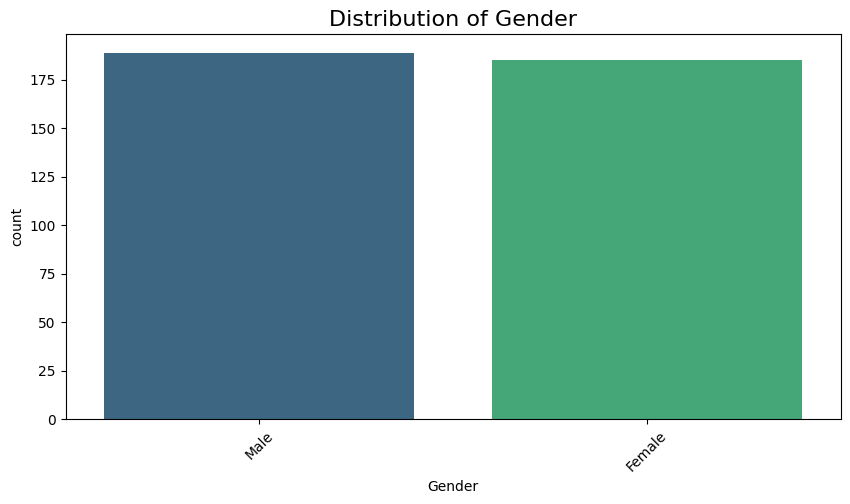

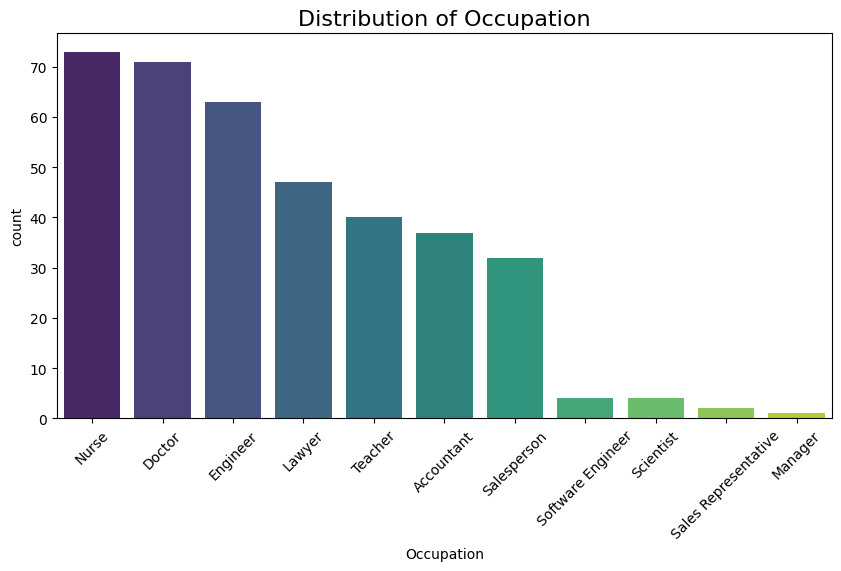

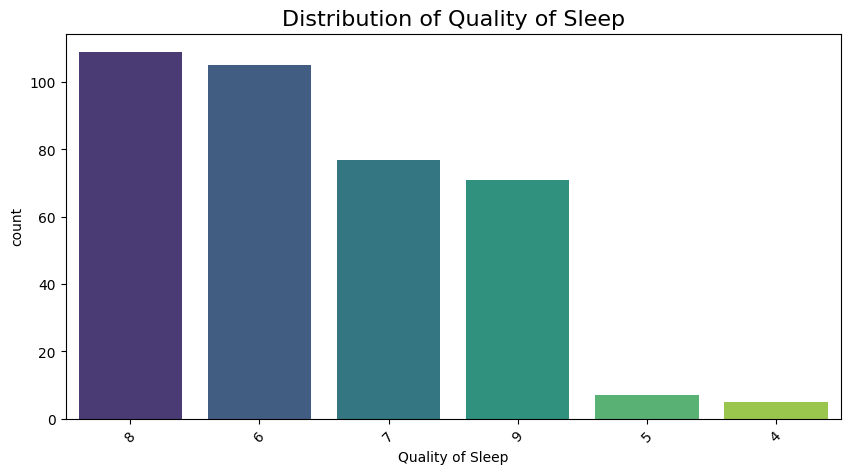

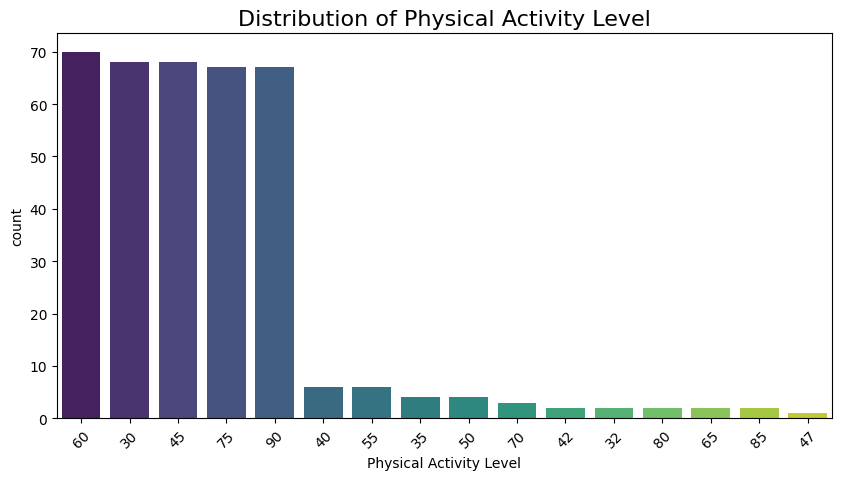

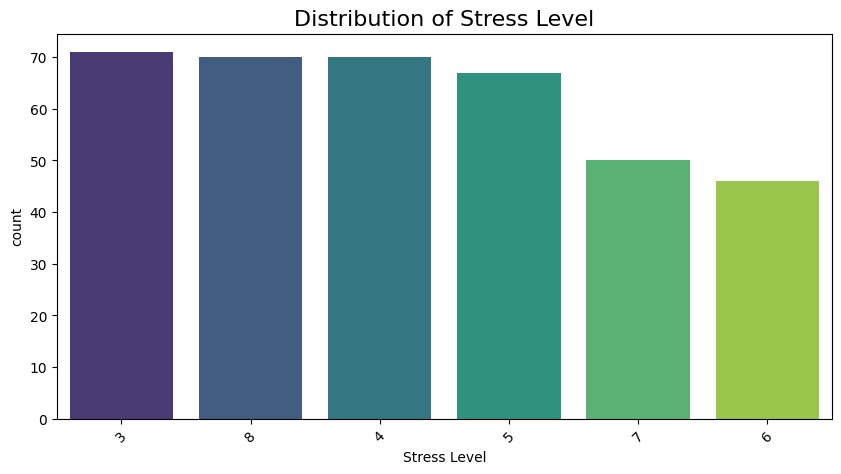

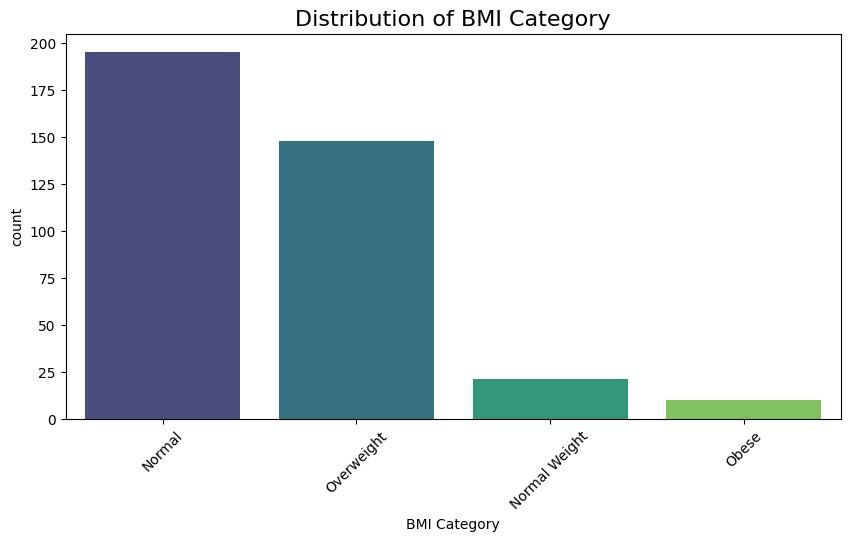

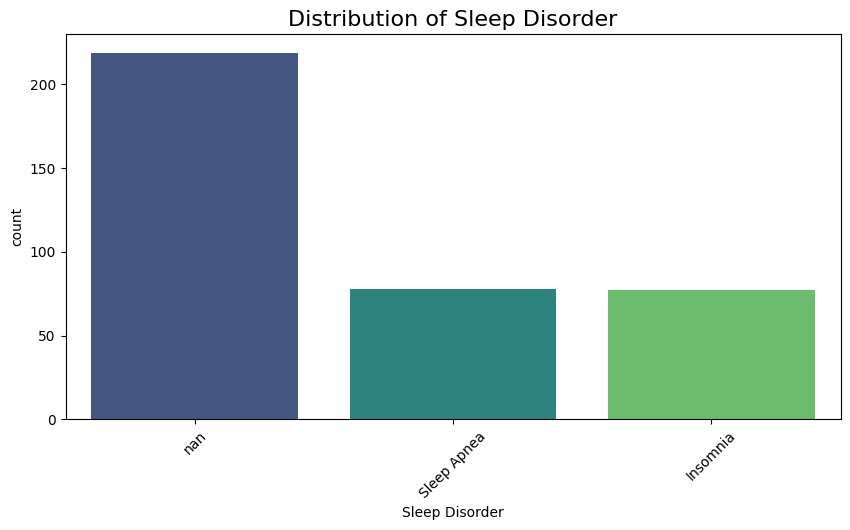

In [13]:
categorical_features = ['Gender', 'Occupation', 'Quality of Sleep', 
                        'Physical Activity Level', 'Stress Level', 
                        'BMI Category', 'Sleep Disorder']

for feature in categorical_features:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=feature, palette="viridis", order=df[feature].value_counts().index)
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()

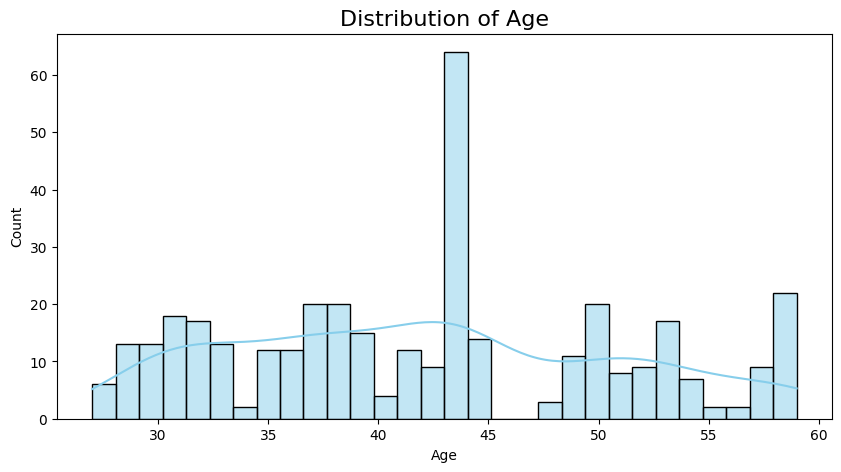

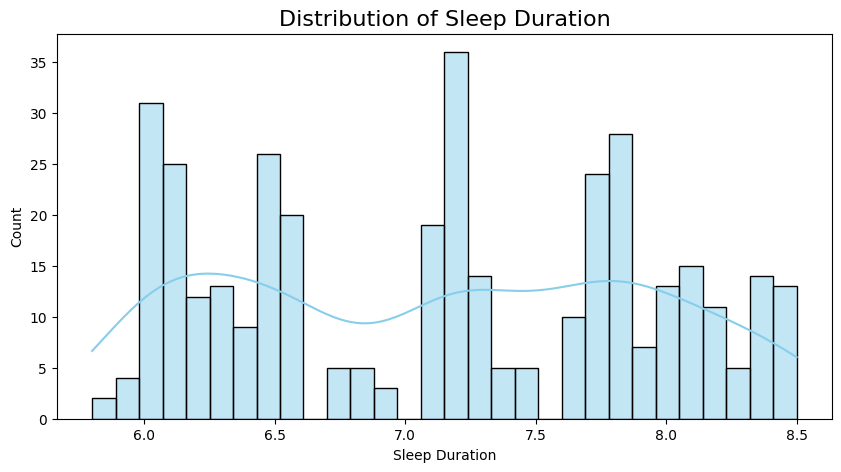

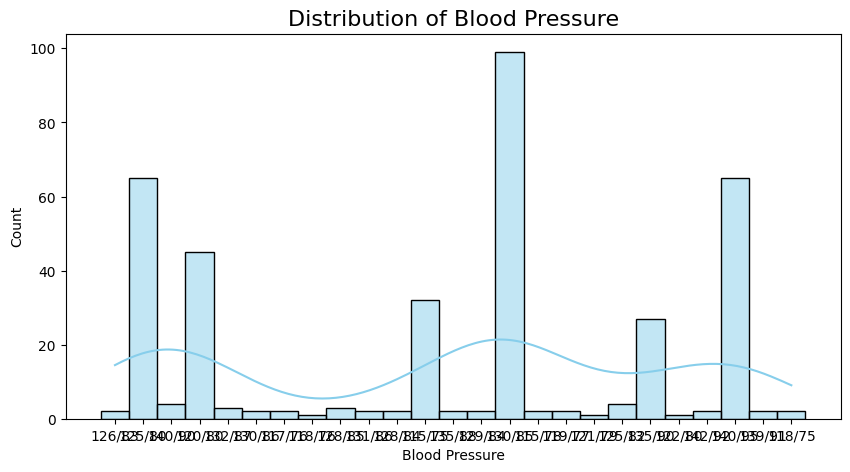

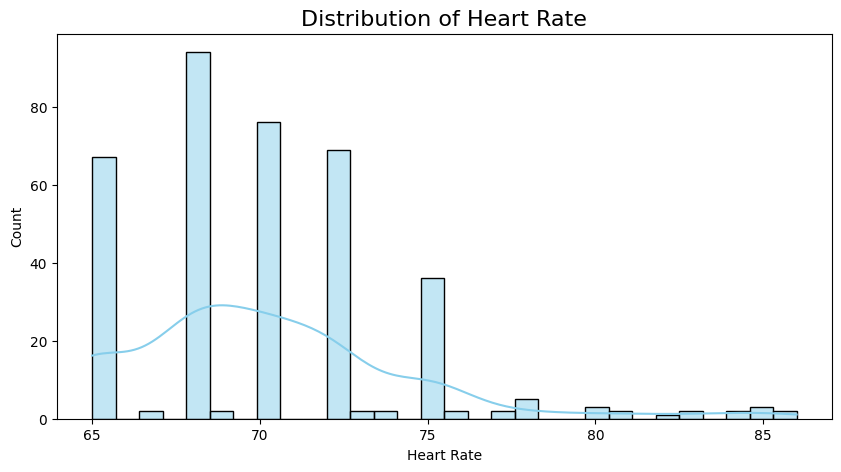

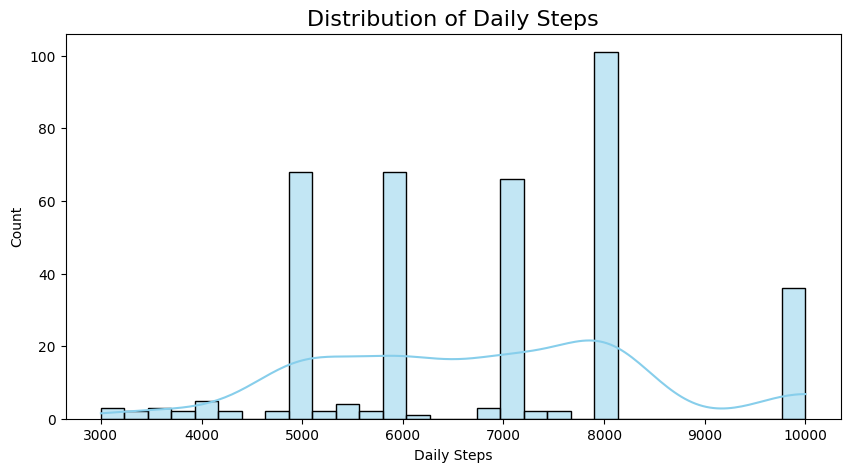

In [14]:
numerical_features = ['Age', 'Sleep Duration', 'Blood Pressure', 'Heart Rate', 'Daily Steps']

for feature in numerical_features:
    plt.figure(figsize=(10,5))
    sns.histplot(df[feature], bins=30, kde=True, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=16)
    plt.show()

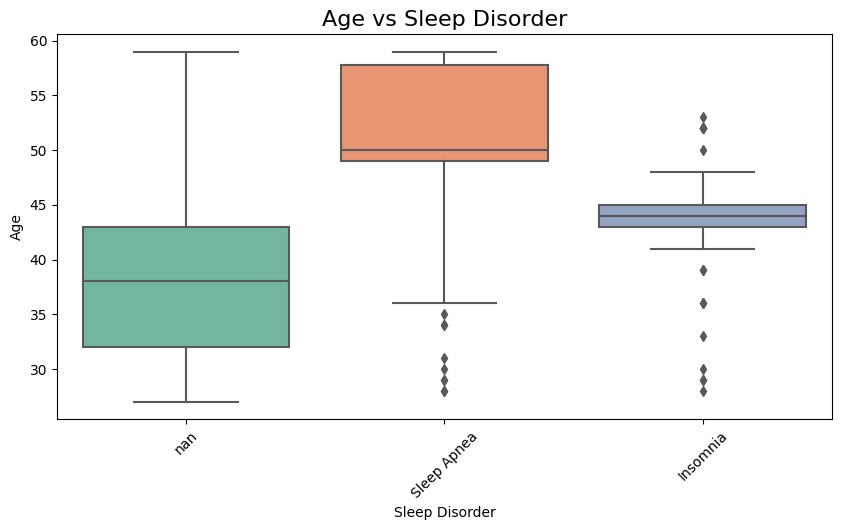

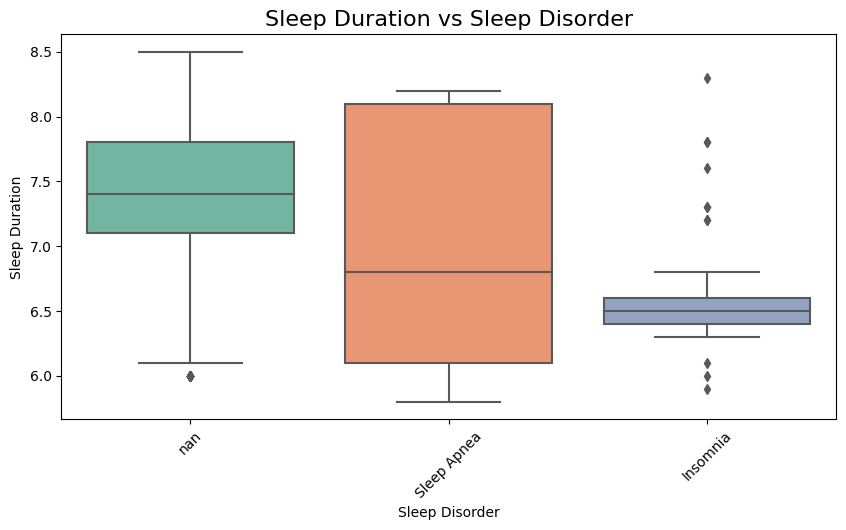

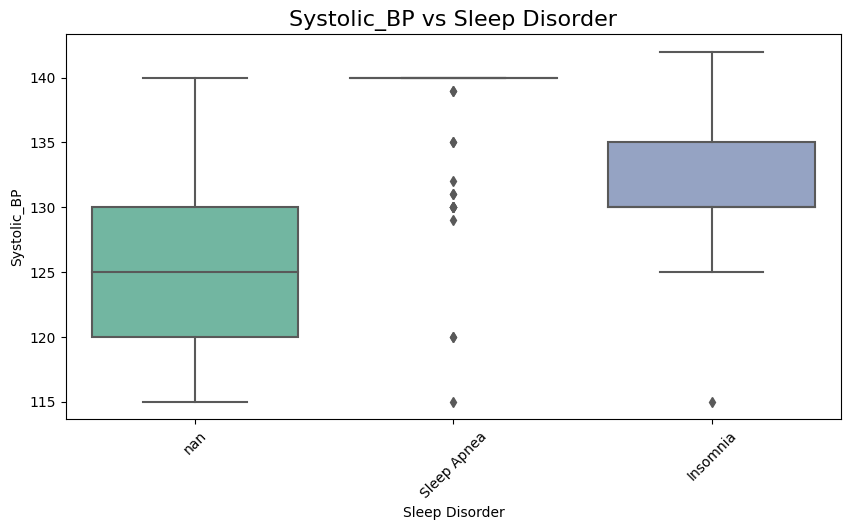

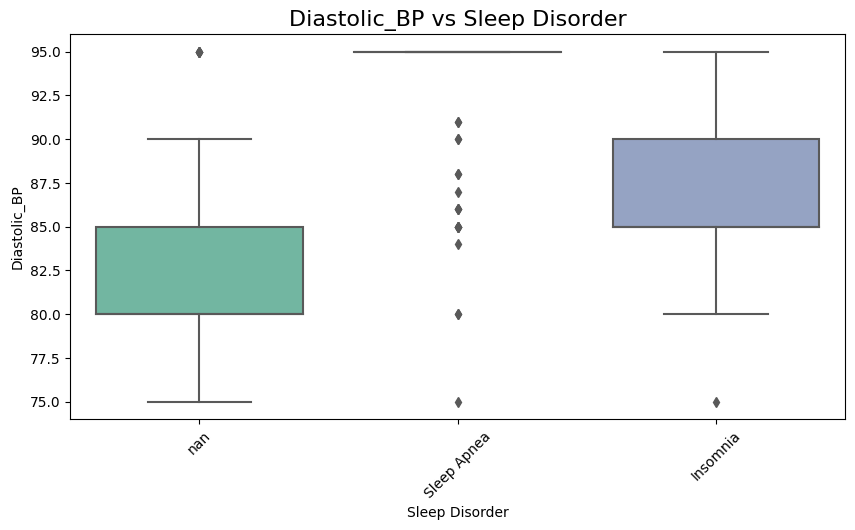

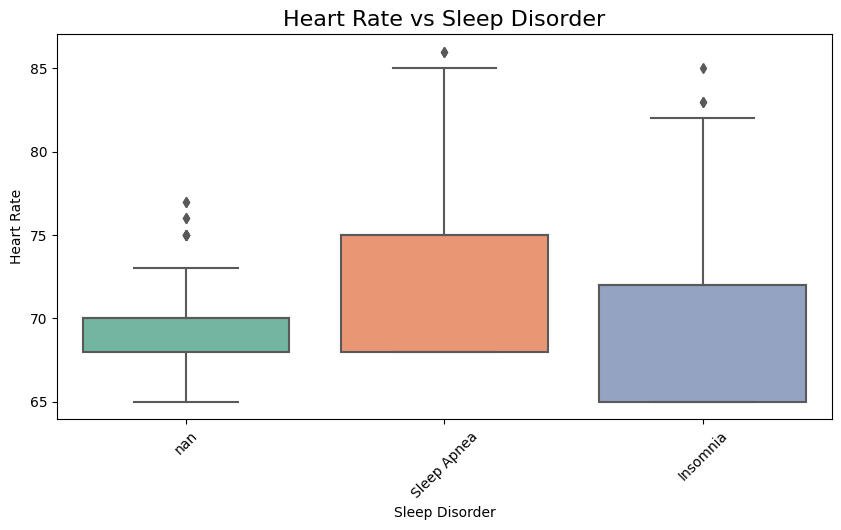

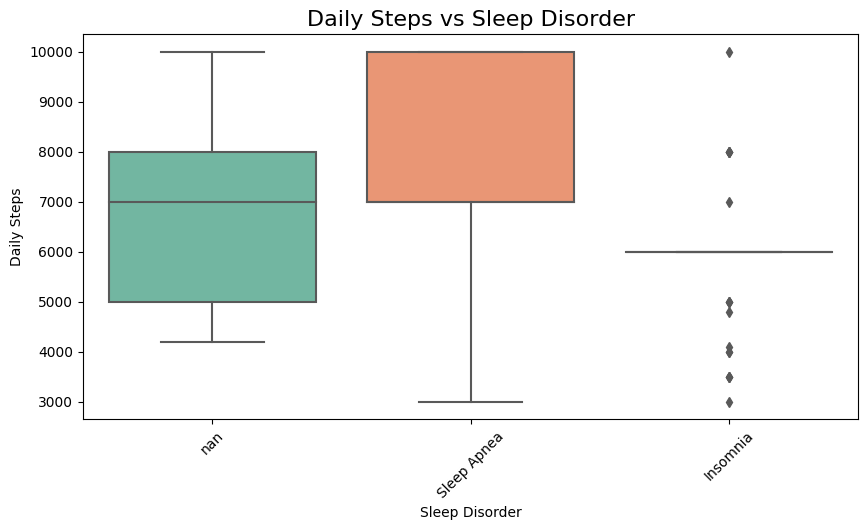

In [15]:
# Convert Sleep Disorder to categorical
df['Sleep Disorder'] = df['Sleep Disorder'].astype(str)

# Ensure all numerical features are numeric
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']
df[numerical_features] = df[numerical_features].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing numerical values for boxplots
df_box = df.dropna(subset=numerical_features + ['Sleep Disorder'])

# Boxplots of numerical features vs Sleep Disorder
for feature in numerical_features:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df_box, x='Sleep Disorder', y=feature, palette='Set2')
    plt.title(f'{feature} vs Sleep Disorder', fontsize=16)
    plt.xticks(rotation=45)
    plt.show()


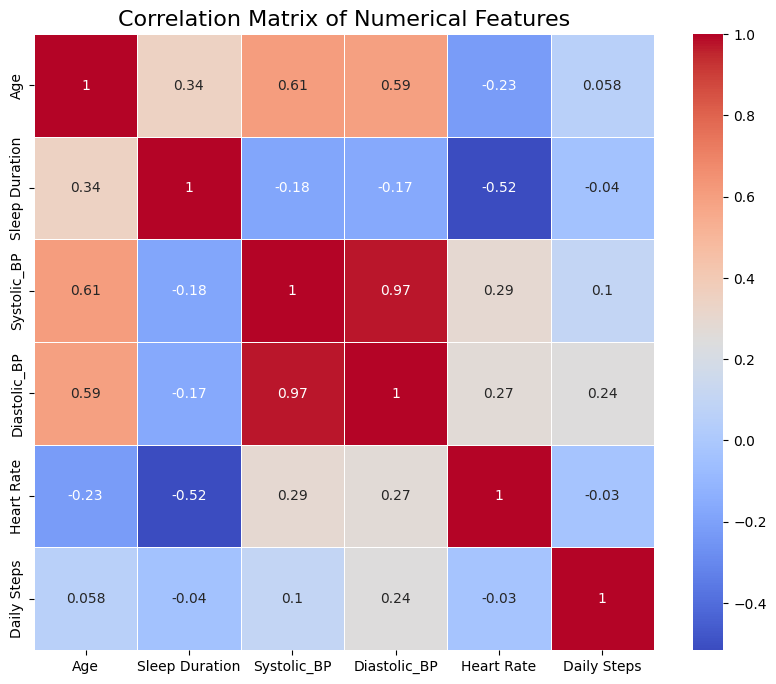

In [16]:
# Split Blood Pressure into Systolic and Diastolic
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(float)

# Update numerical features
numerical_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']

# Correlation Heatmap
plt.figure(figsize=(10,8))
numerical_df = df[numerical_features]
corr = numerical_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()


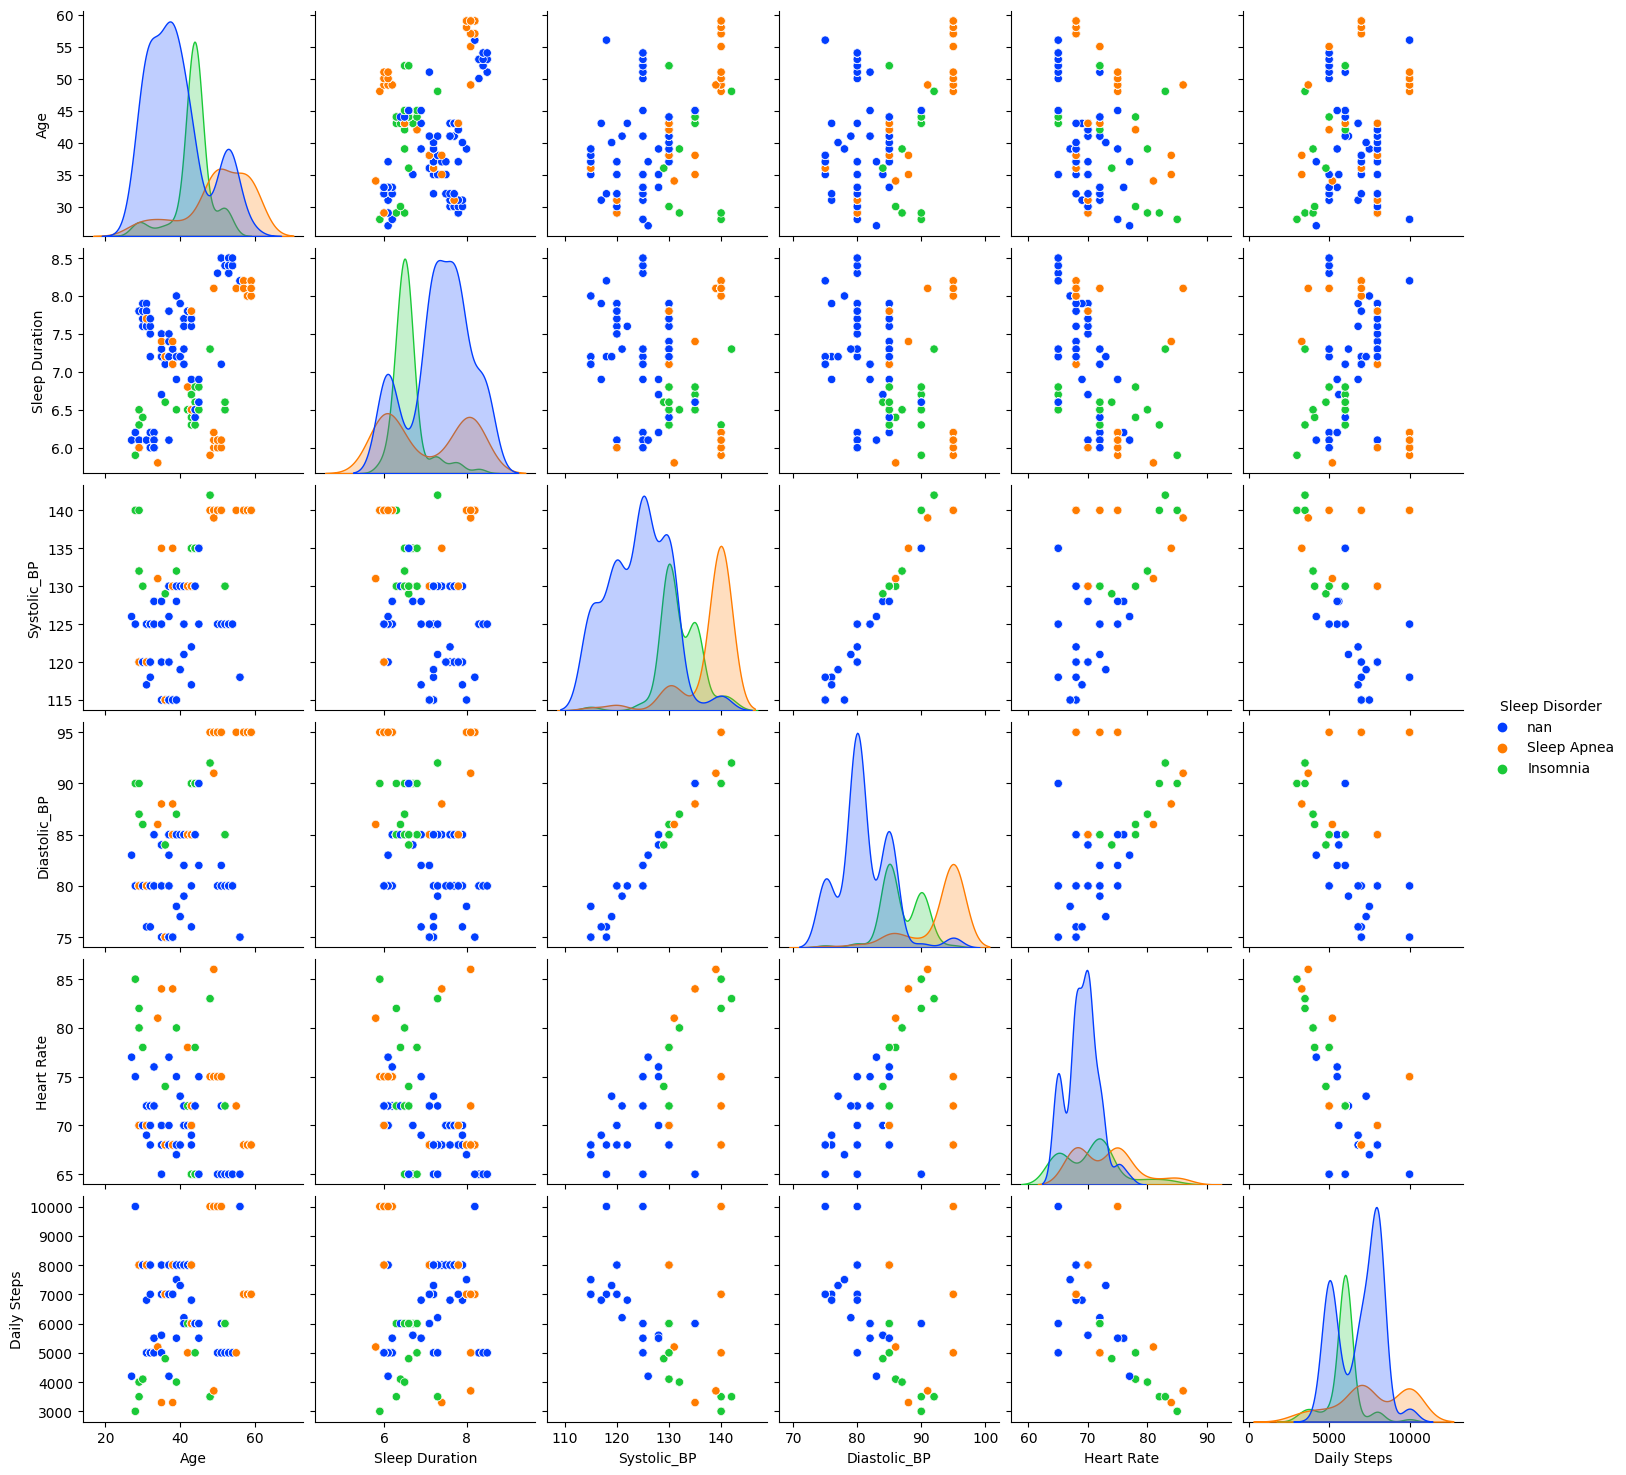

In [17]:
sns.pairplot(df[numerical_features + ['Sleep Disorder']], hue='Sleep Disorder', palette='bright')
plt.show()


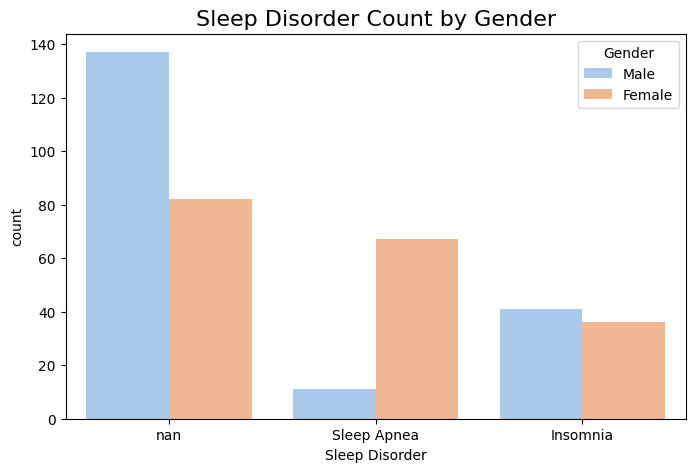

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Sleep Disorder', hue='Gender', palette='pastel')
plt.title('Sleep Disorder Count by Gender', fontsize=16)
plt.show()

## Predtictive modeling

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [20]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = pd.to_numeric(df['Systolic_BP'], errors='coerce')
df['Diastolic_BP'] = pd.to_numeric(df['Diastolic_BP'], errors='coerce')
numeric_features = ['Age', 'Sleep Duration', 'Systolic_BP', 'Diastolic_BP', 'Heart Rate', 'Daily Steps']
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
categorical_features = ['Gender', 'Occupation', 'Quality of Sleep', 
                        'Physical Activity Level', 'Stress Level', 'BMI Category']

le_dict = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
target_le = LabelEncoder()
df['Sleep Disorder'] = target_le.fit_transform(df['Sleep Disorder'].astype(str))
X = df[numeric_features + categorical_features]
y = df['Sleep Disorder']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC()
}

accuracy_dict = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100  
    accuracy_dict[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")

Logistic Regression Accuracy: 88.00%
Decision Tree Accuracy: 89.33%
Random Forest Accuracy: 88.00%
Gradient Boosting Accuracy: 88.00%
K-Nearest Neighbors Accuracy: 85.33%
Support Vector Machine Accuracy: 86.67%


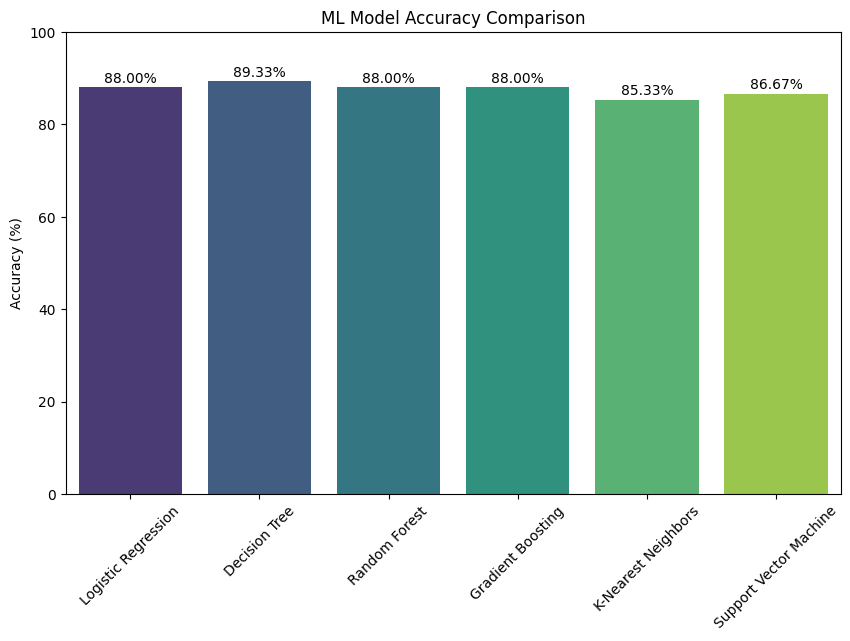

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='viridis')
plt.ylabel('Accuracy (%)')
plt.title('ML Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.ylim(0, 100)
for i, v in enumerate(accuracy_dict.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.show()

## Thank you..pls upvote !!!